In [ ]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [ ]:
!pip install tensorflow==2.15.0


ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.15.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split

#keras libraries
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
import tensorflow as tf
import keras

In [ ]:
print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

TensorFlow version: 2.19.0
Keras version: 3.13.2


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Sentiment Analysis Dataset_100000.csv to Sentiment Analysis Dataset_100000 (1).csv


In [ ]:
df = pd.read_csv('Sentiment Analysis Dataset_100000.csv', encoding='ISO-8859-1')

In [ ]:
df.head()

,ItemID,Sentiment,SentimentText
0,1,0,is so sad for my APL frie...
1,2,0,I missed the New Moon trail...
2,3,1,omg its already 7:30 :O
3,4,0,.. Omgaga. Im sooo im gunna CRy. I'...
4,5,0,i think mi bf is cheating on me!!! ...


In [ ]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['SentimentText'] = df['SentimentText'].apply(clean_text)

In [ ]:
df.dropna(inplace=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df['SentimentText'], df['Sentiment'], test_size=0.2, random_state=42)

In [ ]:
max_words = 5000
tokenizer = Tokenizer(num_words=max_words, oov_token = '<OOV>')
tokenizer.fit_on_texts(X_train)

In [ ]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [ ]:
max_len = 100

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

In [ ]:
model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    Bidirectional(LSTM(64)),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 34s 13ms/step - accuracy: 0.7479 - loss: 0.5099 - val_accuracy: 0.7782 - val_loss: 0.4682
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.7963 - loss: 0.4378 - val_accuracy: 0.7767 - val_loss: 0.4623
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.8174 - loss: 0.4007 - val_accuracy: 0.7761 - val_loss: 0.4717
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.8330 - loss: 0.3686 - val_accuracy: 0.7758 - val_loss: 0.4951


In [ ]:
loss, accuracy = model.evaluate(X_test_pad, y_test)
print("test accuracy:", accuracy)

625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7729 - loss: 0.4709
test accuracy: 0.7729272842407227


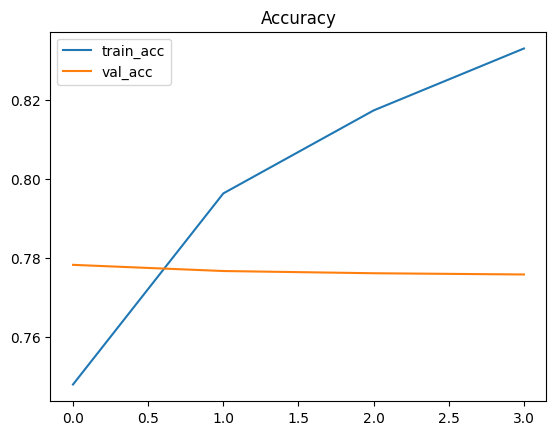

In [ ]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

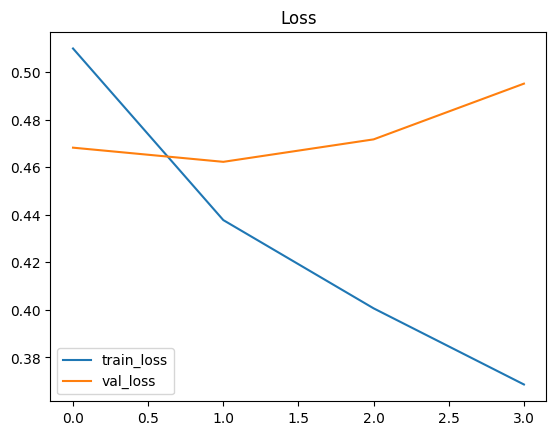

In [ ]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()

In [ ]:
def predict_sentiment(text):
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_len, padding='post')
    pred = model.predict(pad)[0][0]

    return "Positive" if pred > 0.5 else "Negative"

# Example
print(predict_sentiment("I love this product!"))
print(predict_sentiment("This is terrible"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Negative


In [ ]:
# save the moel

import pickle

# model.save('bilstm_sentiment_analysis_model.h5')
model.save('bilstm_sentiment_analysis_model.keras')

with open('tokenizer.pickle', 'wb') as f:
    pickle.dump(tokenizer, f)

In [ ]:
# files.download('bilstm_sentiment_analysis_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#files.download('bilstm_sentiment_analysis_model.h5')

In [ ]:
#files.download('tokenizer.pickle')